In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
def lineStartsWith(line, patterns):
    if isinstance(patterns, str):
        pattern = patterns
        lenPat = len(pattern)
        if len(line) < lenPat:
            return False
        if line[0:lenPat] == pattern:
            return True
        return False
    else:
        for pattern in patterns:
            lenPat = len(pattern)
            if len(line) < lenPat:
                continue
            if line[0:lenPat] == pattern:
                return True
        return False

In [3]:
def createFigure(xVec, yVecs, labelVec, title, xLabel, yLabel, filename=None, xTicks=None, yTicks=None, yScale=None, nDash=0):
    fig,ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    numY = yVecs.shape[0]
    numL = labelVec.shape[0]

    if numY != numL:
        return

    if xTicks != None:
        ax.set_xticks(xTicks)

    if yTicks != None:
        ax.set_yticks(yTicks)
    else:
        pass
        #ax.set_ylim(bottom=1, top=np.max(yVecs)*1.1)

    if yScale != None:
        ax.set_yscale(yScale)

    # Plot the first nDash elements as dashed lines
    for i in range(nDash):
        ax.plot(xVec, yVecs[i], '--', label=labelVec[i])
    # Plot the rest normally
    for i in range(nDash, numY):
        ax.plot(xVec, yVecs[i], label=labelVec[i])

    ax.legend()
    if filename != None:
        fig.savefig(filename)

In [4]:
def parseFile(filename):
    # Row 1 is for qr
    # Row 2 is for lq
    # Column 1 is for Optimized (AOCL)
    # Column 2 is for Recursive bailing to LVL2 termination
    # Column 3 is for Recursive bailing to UT termination
    # Column 4 is for UT computing inverse
    # Column 5 is for UT not computing inverse
    larft_times = np.zeros((2,5))
    larft_perf = np.zeros((2,5))

    qr_opt_time = np.zeros(0)
    qr_ref_2_time = np.zeros(0)
    qr_rec_ut_time = np.zeros(0)
    qr_ut_inv_time = np.zeros(0)
    qr_ut_solve_time = np.zeros(0)

    qr_opt_perf = np.zeros(0)
    qr_ref_2_perf = np.zeros(0)
    qr_rec_ut_perf = np.zeros(0)
    qr_ut_inv_perf = np.zeros(0)
    qr_ut_solve_perf = np.zeros(0)

    lq_opt_time = np.zeros(0)
    lq_ref_2_time = np.zeros(0)
    lq_rec_ut_time = np.zeros(0)
    lq_ut_inv_time = np.zeros(0)
    lq_ut_solve_time = np.zeros(0)

    lq_opt_perf = np.zeros(0)
    lq_ref_2_perf = np.zeros(0)
    lq_rec_ut_perf = np.zeros(0)
    lq_ut_inv_perf = np.zeros(0)
    lq_ut_solve_perf = np.zeros(0)

    nVec = np.zeros(0).astype('int')
    kVec = np.zeros(0).astype('int')
    
    firstRun = True
    numRepeat = 5.0
    with open(filename,'r') as file:
        lines = file.readlines()
        for line in lines:
            if lineStartsWith(line, "m="):
                line2 = line.split(":")
                n = int(line2[0][2:])
                k = int(line2[1][2:])

                nVec = np.append(nVec, n)
                kVec = np.append(kVec, k)
                if firstRun:
                    firstRun = False
                else:
                    # average our current times and performance metric
                    larft_times = larft_times / numRepeat
                    larft_perf = larft_perf / numRepeat

                    qr_opt_time = np.append(qr_opt_time,larft_times[0][0])
                    qr_ref_2_time = np.append(qr_ref_2_time, larft_times[0][1])
                    qr_rec_ut_time = np.append(qr_rec_ut_time, larft_times[0][2])
                    qr_ut_inv_time = np.append(qr_ut_inv_time, larft_times[0][3])
                    qr_ut_solve_time = np.append(qr_ut_solve_time, larft_times[0][4])

                    qr_opt_perf = np.append(qr_opt_perf,larft_perf[0][0])
                    qr_ref_2_perf = np.append(qr_ref_2_perf, larft_perf[0][1])
                    qr_rec_ut_perf = np.append(qr_rec_ut_perf, larft_perf[0][2])
                    qr_ut_inv_perf = np.append(qr_ut_inv_perf, larft_perf[0][3])
                    qr_ut_solve_perf = np.append(qr_ut_solve_perf, larft_perf[0][4])

                    lq_opt_time = np.append(lq_opt_time,larft_times[1][0])
                    lq_ref_2_time = np.append(lq_ref_2_time, larft_times[1][1])
                    lq_rec_ut_time = np.append(lq_rec_ut_time, larft_times[1][2])
                    lq_ut_inv_time = np.append(lq_ut_inv_time, larft_times[1][3])
                    lq_ut_solve_time = np.append(lq_ut_solve_time, larft_times[1][4])

                    lq_opt_perf = np.append(lq_opt_perf,larft_perf[1][0])
                    lq_ref_2_perf = np.append(lq_ref_2_perf, larft_perf[1][1])
                    lq_rec_ut_perf = np.append(lq_rec_ut_perf, larft_perf[1][2])
                    lq_ut_inv_perf = np.append(lq_ut_inv_perf, larft_perf[1][3])
                    lq_ut_solve_perf = np.append(lq_ut_solve_perf, larft_perf[1][4])

                    larft_times = np.zeros((2,5))
                    larft_perf = np.zeros((2,5))
            elif lineStartsWith(line.strip(), ["QR","LQ"]):
                line2 = line.split(":")
                valueString = re.sub(r'\s+', ' ', line2[1].strip())
                values = valueString.split(" ")

                opt_val = float(values[0])
                ref_2_val = float(values[1])
                rec_ut_val = float(values[2])
                ut_inv_val = float(values[3])
                ut_solve_val = float(values[4])

                if lineStartsWith(line.strip(), "QR PERF"):
                    larft_perf[0][0] += opt_val
                    larft_perf[0][1] += ref_2_val
                    larft_perf[0][2] += rec_ut_val
                    larft_perf[0][3] += ut_inv_val
                    larft_perf[0][4] += ut_solve_val
                elif lineStartsWith(line.strip(), "QR TIMES"):
                    larft_times[0][0] += opt_val
                    larft_times[0][1] += ref_2_val
                    larft_times[0][2] += rec_ut_val
                    larft_times[0][3] += ut_inv_val
                    larft_times[0][4] += ut_solve_val
                elif lineStartsWith(line.strip(), "LQ PERF"):
                    larft_perf[1][0] += opt_val
                    larft_perf[1][1] += ref_2_val
                    larft_perf[1][2] += rec_ut_val
                    larft_perf[1][3] += ut_inv_val
                    larft_perf[1][4] += ut_solve_val
                else:
                    larft_times[1][0] += opt_val
                    larft_times[1][1] += ref_2_val
                    larft_times[1][2] += rec_ut_val
                    larft_times[1][3] += ut_inv_val
                    larft_times[1][4] += ut_solve_val
    larft_times = larft_times / numRepeat
    larft_perf = larft_perf / numRepeat

    qr_opt_time = np.append(qr_opt_time,larft_times[0][0])
    qr_ref_2_time = np.append(qr_ref_2_time, larft_times[0][1])
    qr_rec_ut_time = np.append(qr_rec_ut_time, larft_times[0][2])
    qr_ut_inv_time = np.append(qr_ut_inv_time, larft_times[0][3])
    qr_ut_solve_time = np.append(qr_ut_solve_time, larft_times[0][4])
    
    qr_opt_perf = np.append(qr_opt_perf,larft_perf[0][0])
    qr_ref_2_perf = np.append(qr_ref_2_perf, larft_perf[0][1])
    qr_rec_ut_perf = np.append(qr_rec_ut_perf, larft_perf[0][2])
    qr_ut_inv_perf = np.append(qr_ut_inv_perf, larft_perf[0][3])
    qr_ut_solve_perf = np.append(qr_ut_solve_perf, larft_perf[0][4])
    
    lq_opt_time = np.append(lq_opt_time,larft_times[1][0])
    lq_ref_2_time = np.append(lq_ref_2_time, larft_times[1][1])
    lq_rec_ut_time = np.append(lq_rec_ut_time, larft_times[1][2])
    lq_ut_inv_time = np.append(lq_ut_inv_time, larft_times[1][3])
    lq_ut_solve_time = np.append(lq_ut_solve_time, larft_times[1][4])
    
    lq_opt_perf = np.append(lq_opt_perf,larft_perf[1][0])
    lq_ref_2_perf = np.append(lq_ref_2_perf, larft_perf[1][1])
    lq_rec_ut_perf = np.append(lq_rec_ut_perf, larft_perf[1][2])
    lq_ut_inv_perf = np.append(lq_ut_inv_perf, larft_perf[1][3])
    lq_ut_solve_perf = np.append(lq_ut_solve_perf, larft_perf[1][4])

    return (nVec, kVec, \
            qr_opt_time, qr_ref_2_time, qr_rec_ut_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_2_perf, qr_rec_ut_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_2_time, lq_rec_ut_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_2_perf, lq_rec_ut_perf, lq_ut_inv_perf, lq_ut_solve_perf)

In [5]:
(nVec, kVec, \
            qr_opt_time, qr_ref_2_time, qr_rec_ut_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_2_perf, qr_rec_ut_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_2_time, lq_rec_ut_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_2_perf, lq_rec_ut_perf, lq_ut_inv_perf, lq_ut_solve_perf) = parseFile("small.out")

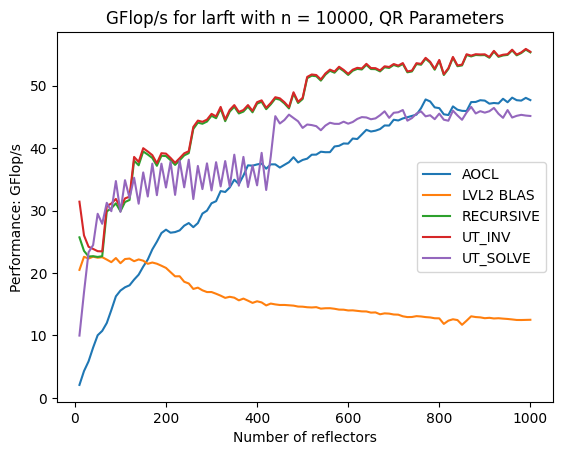

In [6]:
xVec = kVec
yVecs = np.array([qr_opt_perf, qr_ref_2_perf, qr_rec_ut_perf, qr_ut_inv_perf, qr_ut_solve_perf])

labelVecs = np.array(["AOCL", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors"
yLabel = "Performance: GFlop/s"
title = "GFlop/s for larft with n = 10000, QR Parameters"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="qr_larft_10000_k.png")

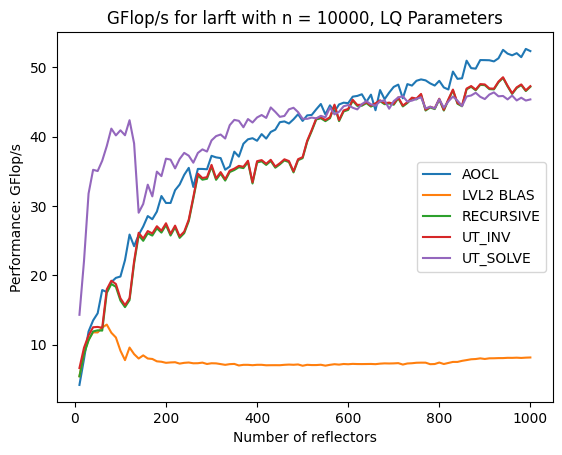

In [7]:
xVec = kVec
yVecs = np.array([lq_opt_perf, lq_ref_2_perf, lq_rec_ut_perf, lq_ut_inv_perf, lq_ut_solve_perf])

labelVecs = np.array(["AOCL", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors"
yLabel = "Performance: GFlop/s"
title = "GFlop/s for larft with n = 10000, LQ Parameters"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="lq_larft_10000_k.png")